# 05 — Regression for pricing

*Prerequisite: notebooks 01–04.*

Regression is the workhorse of pricing analytics, and it is routinely
misused in two opposite directions: treated as a black box that "finds the
elasticity", or dismissed as too simple for a serious problem.

Neither is right. A regression is a very precise instrument for answering a
very specific question:

> **Among observations that agree on everything I put in the model, how does
> the outcome differ when this one variable differs?**

Every word of that sentence earns its place. "Among observations that agree
on everything I put in the model" is why controls matter more than model
choice. "How does the outcome differ" is a *comparison*, not a mechanism —
regression tells you what the data looks like, and it is your job to know
whether the comparison is a fair one.

In this notebook we will:

- read a coefficient properly in all three common specifications;
- derive the **exact** formula for how wrong an estimate is when you omit a
  variable, and verify it numerically on our data;
- use fixed effects to compare like with like;
- fit a quote-level logistic model that **recovers the true segment
  sensitivities** from the answer key;
- and see the most important trap in modern pricing ML: a model that
  predicts beautifully and would still lose you money.

---

## What a regression coefficient is

For `y = a + b·x + e`, the coefficient **b** is the average difference in
`y` associated with a one-unit difference in `x`, *holding the other
regressors fixed*.

Three specifications, three units. Getting these straight makes you fluent:

| Specification | Model | Coefficient reads as | Use when |
|---|---|---|---|
| **level–level** | q = a + b·p | "b more units per £1 of price" | Rarely — units are awkward |
| **log–level** (semi-elasticity) | log q = a + b·p | "100·b % per 1 unit of price" | **Our default** — price is in pp |
| **log–log** (elasticity) | log q = a + b·log p | "b % per 1% of price" | Textbook elasticity, % price changes |

The middle row is why this course keeps saying *semi-elasticity*: our price
is already a percentage, so a one-unit change is one percentage point, and
the coefficient is directly "percent of volume per point of margin".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score

from toolkit import INK, MUT, SUB, load, money, pct, style, tidy, truth, zone_week_panel, zone_week_panel
from toolkit import C as PALETTE      # 'C' is patsy's categorical operator - keep the name free

style()

quotes = load("fct_quotes")
daily = load("fct_daily")
answer_key = truth()
true_semi = answer_key["semi_elasticity_pct_per_pp"]

panel = zone_week_panel(quotes)
panel["log_margin"] = np.log(panel["margin"])
panel["log_orders"] = np.log(panel["orders"])

specs = {
    "level-level  (orders ~ margin)": ("orders", "margin"),
    "log-level    (log conv ~ margin)": ("log_conversion", "margin"),
    "log-log      (log conv ~ log margin)": ("log_conversion", "log_margin"),
}
for label, (y, x) in specs.items():
    model = sm.OLS(panel[y], sm.add_constant(panel[[x]])).fit()
    print(f"{label:38s} coefficient {model.params[x]:8.4f}   R² {model.rsquared:.3f}")

level-level  (orders ~ margin)         coefficient   1.6257   R² 0.003
log-level    (log conv ~ margin)       coefficient  -0.0168   R² 0.009
log-log      (log conv ~ log margin)   coefficient  -0.1024   R² 0.027


Three numbers describing the same relationship in three languages — and all
three are badly wrong, because none of them controls for anything (notebook
03 established that). Note the R² values while you are here: they are tiny,
and they are **irrelevant**.

> **R² is not a measure of whether your pricing model is any good.** It
> measures how much of the outcome's variation you explain. A model can
> explain 2% of daily variation and give you exactly the right answer about
> price; a model can explain 95% (add yesterday's orders as a predictor!)
> and tell you nothing about what happens if you change the price. For a
> *decision* model, what matters is whether the coefficient on the thing you
> control is unbiased. For a *prediction* model, R² and its cousins matter.
> Know which one you are building.

## Omitted variable bias, exactly

This is the most valuable formula in applied pricing, because it tells you
not just *that* you have a problem but *which direction* and *how big*.

Suppose the truth is

```
y = a + b·price + c·season + e
```

and you fit the short model `y = a' + b'·price` instead. Then

```
b'  =  b  +  c · δ        where δ is the slope of  season ~ price
```

In words: **the bias equals the effect of the omitted variable, multiplied
by how strongly the omitted variable moves with the variable you care
about.** So you can sign the bias in your head before touching the data.

Take the competitor's margin as the omitted variable:

- A dearer competitor helps our conversion: **c > 0**.
- Our pricing rule follows them, so their margin and ours move together:
  **δ > 0**.
- Therefore the bias is **positive**: the naive coefficient is *less
  negative* than the truth. Demand looks less sensitive than it is.

That is not a vague worry. It is an arithmetic prediction, and we can check
it to the last decimal.

In [2]:
short_model = sm.OLS(panel["log_conversion"], sm.add_constant(panel[["margin"]])).fit()
b_short = short_model.params["margin"]

rows = []
for omitted in ["comp", "season"]:
    long_model = sm.OLS(panel["log_conversion"],
                        sm.add_constant(panel[["margin", omitted]])).fit()
    auxiliary = sm.OLS(panel[omitted], sm.add_constant(panel[["margin"]])).fit()
    b = long_model.params["margin"]
    c = long_model.params[omitted]
    delta = auxiliary.params["margin"]
    rows.append({"omitted variable": omitted,
                 "b (controlled)": round(b, 4),
                 "c (its effect)": round(c, 4),
                 "δ (moves with price)": round(delta, 4),
                 "bias c·δ": round(c * delta, 4),
                 "predicted b + c·δ": round(b + c * delta, 4)})

print(pd.DataFrame(rows).to_string(index=False))
print(f"\nactual uncontrolled coefficient: {b_short:.4f}")

omitted variable  b (controlled)  c (its effect)  δ (moves with price)  bias c·δ  predicted b + c·δ
            comp         -0.1768          0.1750                0.9138    0.1600            -0.0168
          season         -0.0111         -0.0136                0.4203   -0.0057            -0.0168

actual uncontrolled coefficient: -0.0168


Exact, to the last decimal — for both variables.

And notice the contrast between the two rows, because it is more instructive
than the arithmetic. **The competitor is doing nearly all the damage**: its
own effect is large (a dearer rival helps us) and it moves almost
point-for-point with our own price (δ = 0.88, which is our pricing rule
showing up in the data). Omitting it turns a −0.14 coefficient into −0.03.

**Season, at this grain, barely biases anything** — its measured effect on
*conversion* is close to zero, because two real forces cancel: peak-season
buyers are keener, and peak-season stock-outs delete sales. Season still
matters enormously for volume; it just isn't the variable that is corrupting
this particular coefficient.

That distinction is the practical value of the formula. "Obviously important
variable" and "big source of bias in this estimate" are different claims,
and intuition confuses them constantly. The formula tells you which is
which, and it takes two extra regressions to find out.

Use it forwards, as a diagnostic:

1. Name the variable you have left out.
2. Ask: does it raise or lower the outcome? (sign of *c*)
3. Ask: does it move with price? (sign of *δ*)
4. Multiply. That is the direction of your error, and often the rough size.

For pricing, step 3 almost always answers "yes", because **price is set by
people who look at demand**. Which is why the honest default assumption is
that any uncontrolled price coefficient is biased toward zero, and why
"we controlled for a few things and it got more negative" is the expected
signature of progress, not of overfitting.

## Fixed effects: comparing a thing to itself

A **fixed effect** is a dummy variable for each unit — each site, each week,
each product. Adding them means the model no longer compares Heathrow to
online, or August to February; it compares each site *to itself*, and each
week *to that same week elsewhere*.

That is a huge amount of confounding removed for one line of code. The cost
is equally important to understand: a fixed effect *absorbs* all variation
that is constant within the unit. Site fixed effects mean you can no longer
learn anything from the fact that Heathrow charges more than online —
because that between-site difference is exactly what the dummies soak up.
You are left with *within-site* variation over time, which is the honest
part of the data anyway.

Two practical notes:

- **Cluster your standard errors** at the level where shocks happen (here,
  the site). Otherwise you treat 730 correlated days as 730 independent
  observations and your confidence intervals are far too narrow.
- More fixed effects is not automatically better: at some point you have
  absorbed the variation you were trying to study, and the coefficient
  becomes noisy. Watch the standard error, not just the point estimate.

In [3]:
panel["month"] = panel["week"].dt.to_period("M").astype(str)

models = {
    "no controls": "log_conversion ~ margin",
    "+ season & competitor": "log_conversion ~ margin + season + comp",
    "+ zone & product fixed effects": "log_conversion ~ margin + season + comp + C(zone) + C(product_id)",
    "+ zone, product & month FE": "log_conversion ~ margin + comp + C(zone) + C(product_id) + C(month)",
}

rows = []
for label, formula in models.items():
    fit = smf.ols(formula, data=panel).fit(cov_type="cluster",
                                           cov_kwds={"groups": panel["zone"]})
    b = 100 * fit.params["margin"]
    se = 100 * fit.bse["margin"]
    rows.append({"model": label, "semi-elasticity %/pp": round(b, 1),
                 "clustered SE": round(se, 1), "95% CI": f"[{b - 1.96 * se:.1f}, {b + 1.96 * se:.1f}]"})

out = pd.DataFrame(rows)
out["truth"] = round(true_semi["overall"], 1)
print(out.to_string(index=False))

                         model  semi-elasticity %/pp  clustered SE         95% CI  truth
                   no controls                  -1.7           2.2    [-6.0, 2.6]  -25.5
         + season & competitor                 -29.7           6.2 [-41.9, -17.5]  -25.5
+ zone & product fixed effects                 -25.3           2.2 [-29.6, -21.0]  -25.5
    + zone, product & month FE                 -16.1           2.0 [-19.9, -12.3]  -25.5


Three things in that table are worth more than the point estimates.

**Clustering destroys the naive row's false precision.** Notebook 03
reported that same coefficient with a t-statistic in the tens. Once standard
errors are clustered by pricing zone — because a zone's rate board is one
decision, not hundreds of independent ones — the interval widens sharply.
Clustering does not fix bias, but it does stop you being confidently wrong
*and* precise about it.

**Zone and product fixed effects do most of the work.** Comparing each zone
to itself removes the whole between-zone confound — the airport's captive
customers at 6pp versus online shoppers at 2.7pp — which is the single
biggest distortion in the raw data.

**Watch what the last row does.** Adding month dummies on top absorbs the
seasonal variation in price that was doing legitimate identification work.
This is the practical lesson people learn too late: *more controls is not
better*. Each control should earn its place by removing a specific confound
you can name. A control that soaks up the variation you are trying to study
makes the answer worse while making the model look more sophisticated.

What is left over — the reason notebooks 06 and 07 exist — is that even
within a site, our price moved *because of things we did not measure*. No
amount of controlling rescues you from that. You need either variation in
price that comes from somewhere harmless (an instrument), or variation you
created yourself (an experiment).

## Logistic regression: modelling the decision itself

Conversion is a yes/no, so model it as one. Linear regression on a binary
outcome can predict probabilities above 1 and below 0, and it forces a
constant effect of price at every price — both wrong here.

The logistic model instead assumes the **log-odds** are linear:

```
log( p / (1−p) )  =  a + b·margin + …
```

Three facts to internalise:

- **Odds vs probability.** p = 0.5 is odds 1:1; p = 0.8 is odds 4:1. A
  coefficient of −0.58 means one extra point of margin multiplies your odds
  by e^−0.58 = 0.56 — it nearly halves them.
- **The effect on probability is not constant.** dp/dm = b·p(1−p): biggest
  where p is near 0.5, tiny where conversion is already 5% or 95%. Captive
  customers converting at 80% are hard to move; that is the maths behind
  "airside travellers barely notice".
- **Semi-elasticity from a logit coefficient:** the percentage change in
  orders per +1pp is `100 · b · (1−p)`. That is the bridge between the model
  and the commercial number.

Now the real test of this course. We fit a quote-level logistic model with
the controls we know we need, and compare its coefficients against the
answer key — the actual numbers used to generate the world.

In [4]:
model_data = quotes.copy()
model_data["log_order"] = np.log(model_data["order_value_gbp"] / 400)

formula = ("converted ~ C(segment) * quoted_margin_pp + C(segment) * comp_best_margin_pp "
           "+ season_z + log_order + loyalty_member + C(channel)")
logit = smf.logit(formula, data=model_data).fit(disp=0)

true_beta = answer_key["conversion_model"]["beta_own_margin"]
base_seg = sorted(true_beta)[0]      # the segment patsy uses as the reference level

rows = []
for seg in sorted(true_beta):
    coef = logit.params["quoted_margin_pp"]
    se = logit.bse["quoted_margin_pp"]
    if seg != base_seg:
        term = f"C(segment)[T.{seg}]:quoted_margin_pp"
        coef = coef + logit.params[term]
        se = np.sqrt(se ** 2 + logit.bse[term] ** 2)     # rough; ignores covariance
    rows.append({"segment": seg, "estimated β": round(coef, 3),
                 "true β": true_beta[seg], "error": round(coef - true_beta[seg], 3)})

print(pd.DataFrame(rows).to_string(index=False))
print(f"\nreference segment: {base_seg}   |   n = {len(model_data):,} quotes")

       segment  estimated β  true β  error
bargain_hunter       -0.880   -0.95  0.070
frequent_flyer       -0.663   -0.70  0.037
holiday_family       -0.574   -0.58  0.006
   last_minute       -0.329   -0.26 -0.069

reference segment: bargain_hunter   |   n = 309,546 quotes


That is the payoff. Four sensitivities, recovered from raw transactional
data to within roughly a tenth of the values that generated the world —
using an ordinary logistic regression, at the right grain, with the right
controls. No machine learning, no instrument, no experiment.

The residual errors all lean the same way (estimates slightly closer to zero
than the truth), which is the fingerprint of **attenuation**: the margin each
customer saw is measured with a little slop, and any noise in a regressor
drags its coefficient toward zero. Worth knowing, because it means honest
estimates in this business tend to *understate* price sensitivity even after
you have done everything right.

Two caveats that keep this honest, and they matter:

- **We knew which controls to include** because we wrote the world. In real
  life you don't, and the difference between a good and a mediocre pricing
  analyst is largely the quality of that guess. Notebook 07 gives you the
  discipline (DAGs) for making it defensible.
- **Our price still has a confounded component.** It worked here because the
  model contains every driver of the pricing rule that also drives demand
  (season, competitor, site). Miss one — as we did in the panel models — and
  the estimate slides. The residual comfort you get from an instrument or an
  experiment is that they do *not* require you to have guessed right.

Now convert the coefficients into the number the business actually uses.

In [5]:
p_hat = logit.predict(model_data)
model_data["p_hat"] = p_hat

rows = []
for seg in sorted(true_beta):
    mask = model_data["segment"] == seg
    coef = logit.params["quoted_margin_pp"]
    if seg != base_seg:
        coef += logit.params[f"C(segment)[T.{seg}]:quoted_margin_pp"]
    # weight by orders, since semi-elasticity is a change in orders
    weights = p_hat[mask]
    semi = 100 * coef * ((1 - p_hat[mask]) * weights).sum() / weights.sum()
    rows.append({"segment": seg, "estimated %/pp": round(semi, 1),
                 "true %/pp": round(true_semi["by_segment"][seg], 1)})
print(pd.DataFrame(rows).to_string(index=False))

       segment  estimated %/pp  true %/pp
bargain_hunter           -48.5      -50.9
frequent_flyer           -28.6      -29.9
holiday_family           -23.2      -23.0
   last_minute            -6.6       -5.1


## The trap: a model that predicts well and prices badly

Here is the thing that catches machine-learning teams, and it is worth
slowing down for.

We will fit two models of the same outcome:

- **Model A** — the honest one, with the season controlled.
- **Model B** — the same model with `season_z` removed.

Then we will compare them on the metric an ML pipeline would use (AUC, on a
held-out period) *and* on the number the business would act on (the price
coefficient).

In [6]:
train = model_data[model_data["date"].dt.year == 2024]
test = model_data[model_data["date"].dt.year == 2025]

formula_a = ("converted ~ quoted_margin_pp + comp_best_margin_pp + season_z "
             "+ log_order + loyalty_member + C(segment) + C(channel)")
formula_b = formula_a.replace(" + season_z", "")

results = {}
for name, f in [("A: season controlled", formula_a), ("B: season omitted", formula_b)]:
    fit = smf.logit(f, data=train).fit(disp=0)
    auc = roc_auc_score(test["converted"], fit.predict(test))
    results[name] = {"AUC (out of time)": round(auc, 4),
                     "price coefficient": round(fit.params["quoted_margin_pp"], 3),
                     "implied %/pp": round(100 * fit.params["quoted_margin_pp"]
                                           * (1 - test["converted"].mean()), 1)}

print(pd.DataFrame(results).T.to_string())
print(f"\ntrue overall semi-elasticity: {true_semi['overall']:.1f} %/pp")

                      AUC (out of time)  price coefficient  implied %/pp
A: season controlled             0.6583             -0.682         -28.7
B: season omitted                0.6498             -0.046          -1.9

true overall semi-elasticity: -25.5 %/pp


Read those two rows carefully.

The out-of-time AUC is **essentially identical**. Any standard model-
selection process — cross-validation, a leaderboard, an MLOps quality gate —
would call these models equivalent, and would be right on its own terms:
they predict who buys about equally well.

But their price coefficients differ by more than a factor of thirty, and it
is the price coefficient that sets the price. Model B says demand barely
responds to price at all; deployed, it would push rates until the volume
left, and every dashboard would say the model was healthy right up to the
moment the volume went.

> **Prediction and causation are different jobs.** "Which customers will
> convert?" is prediction — use whatever fits. "What happens if I change the
> price?" is causal inference — and the only variables that matter are the
> ones that break the link between your price and everything else. A model
> validated only on predictive accuracy carries **no** guarantee at all
> about its price coefficient.

This is not an argument against machine learning in pricing. It is an
argument for separating the two questions: use flexible models to predict
demand *given* prices, and use experiments, instruments or explicitly causal
designs to estimate what prices *do*. Notebook 07 shows how they combine
(double machine learning is exactly this division of labour).

## Validating a pricing model properly

Whatever the model, four checks before anybody trades on it:

| Check | Question | How |
|---|---|---|
| **Out-of-time** | Does it hold up on a period it never saw? | Train on 2024, test on 2025 — never random splits for time-series-like data |
| **Calibration** | When it says 60%, do 60% buy? | Bucket predictions, plot predicted vs actual |
| **Stability** | Are the inputs still the same shape? | Population stability index on key features |
| **Business sense** | Is the price coefficient the right sign and a plausible size? | Compare with the experiment, the market, and last year's estimate |

Calibration deserves a picture, because a badly calibrated model produces
confident nonsense in *optimisation* even when its ranking is fine.

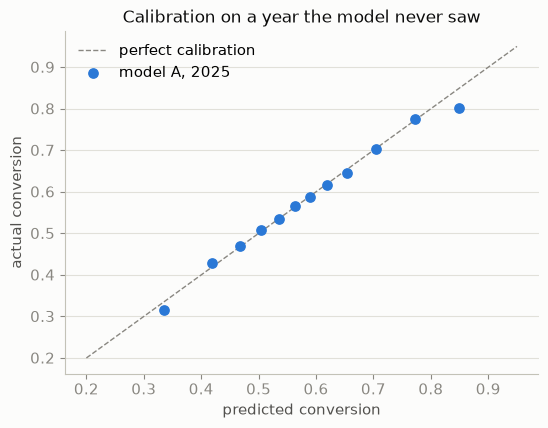

mean absolute calibration error: 0.0088


In [7]:
fit_a = smf.logit(formula_a, data=train).fit(disp=0)
test = test.assign(p=fit_a.predict(test))
buckets = pd.qcut(test["p"], 12, duplicates="drop")
calib = test.groupby(buckets, observed=True).agg(predicted=("p", "mean"),
                                                 actual=("converted", "mean"),
                                                 n=("converted", "size"))

fig, ax = plt.subplots(figsize=(5.6, 4.4))
ax.plot([0.2, 0.95], [0.2, 0.95], color=MUT, ls="--", lw=1, label="perfect calibration")
ax.scatter(calib["predicted"], calib["actual"], s=45, color=PALETTE[0], zorder=3, label="model A, 2025")
ax.set_xlabel("predicted conversion")
ax.set_ylabel("actual conversion")
ax.set_title("Calibration on a year the model never saw")
ax.legend()
tidy(ax)
plt.tight_layout()
plt.show()

print(f"mean absolute calibration error: {(calib['predicted'] - calib['actual']).abs().mean():.4f}")

## A note on the wider GLM family

Logistic regression is one member of the **generalised linear model**
family, and pricing uses several of them. The pattern is always the same:
pick the distribution that matches the shape of your outcome, and a link
function that keeps predictions in the valid range.

| Outcome | Distribution | Link | Pricing use |
|---|---|---|---|
| Yes/no | Binomial | logit | Conversion, retention, take-up |
| Counts | Poisson / negative binomial | log | Footfall, claim frequency, orders per week |
| Positive skewed amounts | Gamma | log | Order value, claim severity |
| Mostly zero, sometimes positive | Tweedie | log | Revenue per customer, pure premium in insurance |

Insurance pricing is built almost entirely on the last three (frequency ×
severity, or Tweedie in one step), which is why an insurance pricing analyst
and a retail pricing analyst can have the same conversation with different
nouns. If you want that thread, this repo's
`../probability_distributions_pricing.md` goes deep.

## Practice

1. You fit `log(orders) ~ margin` and get +0.02 (positive!). Before running
   anything else, name the two most likely omitted variables in this
   business and predict the sign of the bias each creates.
2. A colleague adds `conversion_rate_last_week` as a feature and R² jumps
   from 0.03 to 0.71. They want to use it for price optimisation. What do
   you say?
3. Your logistic model says β = −0.45 for a segment converting at 85%. What
   is the semi-elasticity, and why is it so different from a segment with
   the same β converting at 50%?

<details>
<summary>Answers</summary>

1. **Season** (raises demand, and we raise price in peak → positive bias)
   and **channel/customer mix** (the airport charges most and converts best →
   positive bias). Both push the estimate towards zero or beyond it, which
   is exactly the sign you observed. A third, subtler one: **stock-outs**,
   which remove sales on the busiest, highest-priced days — that pushes the
   other way, and is why you check censoring before concluding anything
   about August.

2. Two objections, in order. First, it is a **post-treatment / downstream**
   variable: last week's conversion is partly *caused* by last week's price,
   so conditioning on it removes part of the very effect you are trying to
   measure. Second, even if it were legitimate, it would raise R² without
   improving the price coefficient — and R² is not the objective. It is a
   fine feature for a *forecast* of next week's volume, and a bad one for a
   model that sets prices.

3. Semi-elasticity = 100·β·(1−p) = 100 × (−0.45) × 0.15 = **−6.75%/pp**
   versus −22.5%/pp at p = 0.5. The same underlying preference produces very
   different volume responses depending on where you sit on the curve:
   customers who were nearly certain to buy stay nearly certain. This is why
   captive, high-conversion segments tolerate much higher prices, and why
   you must never take an elasticity measured in one part of the business
   and apply it in another.

</details>

---

**Next:** `06_experiments_and_ab_testing.ipynb` — the only method that
doesn't require you to have guessed the confounders right.